# Build a multimodal language model with JAX

This tutorial extends [miniGPT](minigpt.md) to handle images alongside text. You will build a small multimodal language model that learns to caption MNIST digits by projecting image patches directly into the token sequence — the same core idea used in [LLaVA](https://arxiv.org/abs/2304.08485).

The model uses **Multimodal Rotary Position Embeddings (M-RoPE)** from [Qwen2-VL](https://arxiv.org/abs/2409.12191): image tokens are assigned independent 2D spatial positions (row, col) while text tokens get standard 1D sequential positions, with no separate learned positional embedding table.

Here, you will learn how to:

- Turn image patches into token embeddings with a linear patch projector
- Assign 2D spatial positions to image tokens and 1D positions to text tokens with M-RoPE
- Build a causal transformer that jointly attends over image and text tokens
- Train the model to generate image captions from scratch

## Setup

In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax
import numpy as np
import matplotlib.pyplot as plt
from tensorboardX import SummaryWriter
import random
import functools
import tiktoken
from datasets import load_dataset

## Tokenizer

We use the same GPT-2 tokenizer from [Tiktoken](https://github.com/openai/tiktoken) as in the miniGPT tutorial, giving the model a full-sized vocabulary consistent with a real language model.

To make training more interesting, each image is paired with a caption drawn at random from several templates.

In [2]:
tokenizer  = tiktoken.get_encoding("gpt2")
BOS = EOS  = tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0]
PAD        = 0
VOCAB_SIZE = tokenizer.n_vocab

## Dataset: MNIST with captions

We pair every digit image with a templated caption such as `"the digit is seven"`. The model learns to generate the caption given the image.

In [3]:
mnist   = load_dataset("ylecun/mnist")
x_train = np.stack([np.array(img) for img in mnist['train']['image']]).astype(np.float32) / 255.0
y_train = np.array(mnist['train']['label'])
x_test  = np.stack([np.array(img) for img in mnist['test']['image']]).astype(np.float32)  / 255.0
y_test  = np.array(mnist['test']['label'])

DIGIT_NAMES = ['zero', 'one', 'two', 'three', 'four',
               'five', 'six', 'seven', 'eight', 'nine']

CAPTION_TEMPLATES = [
    "the digit is {word}",
    "this shows the number {word}",
    "I see a {word}",
    "the handwritten digit {word}",
    "a picture of {word}",
    "this digit is {word}",
]

# TEXT_LEN must cover the longest possible encoded caption (BOS + tokens).
TEXT_LEN = max(
    len([BOS] + tokenizer.encode(tmpl.format(word=d)))
    for tmpl in CAPTION_TEMPLATES
    for d in DIGIT_NAMES
)

In [4]:
def encode_caption(label: int, template: str | None = None) -> list[int]:
    """Encode a digit label using a randomly chosen (or specified) caption template."""
    tmpl   = template or random.choice(CAPTION_TEMPLATES)
    tokens = [BOS] + tokenizer.encode(tmpl.format(word=DIGIT_NAMES[label]))
    return tokens + [PAD] * (TEXT_LEN - len(tokens))

def decode_tokens(ids) -> str:
    valid = [int(i) for i in ids if int(i) not in (PAD, BOS, EOS)]
    return tokenizer.decode(valid)

The training objective is **next-token prediction** on the text part of the sequence.
Given the image and all previous text tokens, the model predicts the next token:

| Input  | `<bos>` | `the`   | `digit` | `is`    | `seven` |
|--------|---------|---------|---------|---------|---------|
| Target | `the`   | `digit` | `is`    | `seven` | `<eos>` |

The loss is computed only over the text positions — not over the image patches. 

In [5]:
def make_batch(images: np.ndarray, labels: np.ndarray):
    """Build (images, text_inputs, text_targets) JAX arrays for a batch."""
    B = len(labels)
    text_in  = np.array([encode_caption(lbl) for lbl in labels], dtype=np.int32)
    text_out = np.concatenate(
        [text_in[:, 1:], np.full((B, 1), EOS, dtype=np.int32)], axis=1
    )
    return jnp.array(images), jnp.array(text_in), jnp.array(text_out)

## Model architecture

The model has four components assembled into `MultimodalGPT`:

1. **`PatchEmbedding`** — splits each 28×28 image into 16 non-overlapping 7×7 patches and projects each flattened patch to `embed_dim` with a single linear layer.
2. **Token embedding** — a standard `nnx.Embed` lookup that maps text token IDs to `embed_dim` vectors.
3. **Causal transformer** — a stack of pre-norm transformer blocks. Each block uses `nnx.MultiHeadAttention` with a custom M-RoPE `attention_fn` so image patches and text tokens share the same sequence but carry different positional coordinates.
4. **LM head** — a linear projection from `embed_dim` to `vocab_size`, applied only to the text positions of the output. The image patch outputs are discarded because the loss is computed purely on text.

The 16 image tokens are prepended to the text tokens and the combined sequence is processed jointly by the transformer. M-RoPE lets the model distinguish image patches by their 2D spatial location and text tokens by their sequential order.

### Patch embedding

We divide each 28×28 image into a 4×4 grid of 7×7 patches, yielding **16 image tokens**. A single linear layer projects each flattened patch to `embed_dim`.

In [6]:
class PatchEmbedding(nnx.Module):
    """Project image patches into the model's embedding space."""

    def __init__(self, patch_size: int, embed_dim: int, *, rngs: nnx.Rngs):
        self.patch_size = patch_size
        self.proj = nnx.Linear(patch_size * patch_size, embed_dim, rngs=rngs)

    def __call__(self, images):
        # images: (B, H, W)
        B, H, W = images.shape
        p = self.patch_size
        nh, nw = H // p, W // p
        x = images.reshape(B, nh, p, nw, p).transpose(0, 1, 3, 2, 4)  # (B, nh, nw, p, p)
        return self.proj(x.reshape(B, nh * nw, p * p))                # (B, num_patches, embed_dim)

### Multimodal Rotary Position Embedding (M-RoPE)

Standard RoPE assigns a single sequential integer to each token. M-RoPE extends this for multimodal sequences by **splitting the attention head dimension into two equal halves**:

- **First half** is rotated by the *row* index (image patches) or *sequence position* (text).
- **Second half** is rotated by the *column* index (image patches) or *sequence position* (text).

For text tokens both halves receive the same value, so M-RoPE reduces to standard 1D RoPE. For image patches the two halves carry independent row and column coordinates, encoding 2D location without any additional embedding table.

```
Sequence layout:  [patch(0,0)  patch(0,1) … patch(3,3) | <bos>  the  digit  is  <word>]
                  ←————————————16 image tokens—————————→ ←————5 text tokens————→

M-RoPE pos_0:     [0  0  0  0  1  1  1  1  2  2  2  2  3  3  3  3 | 4  5  6  7  8]  (row / seq)
M-RoPE pos_1:     [0  1  2  3  0  1  2  3  0  1  2  3  0  1  2  3 | 4  5  6  7  8]  (col / seq)
```

In [7]:
def make_mrope_positions(grid_h: int, grid_w: int, text_len: int):
    """Return per-token M-RoPE position IDs as two 1-D arrays.

    Image patches get independent (row, col) positions. Text tokens get a
    sequential position in both components, offset past the image grid so
    image and text coordinates do not collide.
    """
    rows = jnp.repeat(jnp.arange(grid_h), grid_w)
    cols = jnp.tile(jnp.arange(grid_w), grid_h)
    text_seq = jnp.arange(text_len) + max(grid_h, grid_w)
    return jnp.concatenate([rows, text_seq]), jnp.concatenate([cols, text_seq])

### Attention, transformer blocks, and the full model

M-RoPE is implemented with `dot_product_attention_with_mrope`, a thin extension of
`nnx.dot_product_attention_with_rope` for 2D positions. It accepts `input_positions`
as a `[2, seq_len]` array where row 0 holds row/sequence indices and row 1 holds
column/sequence indices. The first and second halves of each head's dimension are
rotated independently by `nnx.RoPE`, then concatenated before the standard
dot-product attention is computed. `nnx.MultiHeadAttention` takes this function as
its `attention_fn`, so all Q/K/V projections and the output projection are handled
by the built-in module.

In [18]:
def dot_product_attention_with_mrope(
    query, key, value, *, rope, input_positions, **kwargs
):
    """Dot-product attention with Multimodal RoPE.

    Extends nnx.dot_product_attention_with_rope for 2D spatial positions.
    ``input_positions`` must be a [2, seq_len] array: row 0 contains row/sequence
    indices (pos_0) and row 1 contains column/sequence indices (pos_1).  Image
    patches receive independent (row, col) coordinates; text tokens receive the
    same value in both rows (standard 1-D RoPE behaviour).
    """
    pos_0, pos_1 = input_positions[0], input_positions[1]
    h = query.shape[-1] // 2
    apply = jax.vmap(rope, in_axes=(-2, None), out_axes=-2)
    query = jnp.concatenate([apply(query[..., :h], pos_0), apply(query[..., h:], pos_1)], axis=-1)
    key   = jnp.concatenate([apply(key  [..., :h], pos_0), apply(key  [..., h:], pos_1)], axis=-1)
    return nnx.dot_product_attention(query, key, value, **kwargs)

In [9]:
class CausalSelfAttention(nnx.Module):
    """Causal multi-head self-attention with M-RoPE via nnx.MultiHeadAttention."""

    def __init__(self, embed_dim: int, num_heads: int, *, rngs: nnx.Rngs):
        assert embed_dim % num_heads == 0
        assert (embed_dim // num_heads) % 4 == 0, "head_dim must be divisible by 4 for M-RoPE"
        self.attn = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=embed_dim,
            use_bias=False,
            decode=False,
            attention_fn=functools.partial(dot_product_attention_with_mrope, rope=nnx.RoPE()),
            rngs=rngs,
        )

    def __call__(self, x, pos_0, pos_1):
        return self.attn(x, is_causal=True, input_positions=jnp.stack([pos_0, pos_1]))

In [10]:
class TransformerBlock(nnx.Module):
    """Pre-norm transformer block."""

    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, *, rngs: nnx.Rngs):
        self.attn  = CausalSelfAttention(embed_dim, num_heads, rngs=rngs)
        self.fc1   = nnx.Linear(embed_dim, ff_dim, rngs=rngs)
        self.fc2   = nnx.Linear(ff_dim, embed_dim, rngs=rngs)
        self.norm1 = nnx.LayerNorm(num_features=embed_dim, rngs=rngs)
        self.norm2 = nnx.LayerNorm(num_features=embed_dim, rngs=rngs)

    def __call__(self, x, pos_0, pos_1):
        x = x + self.attn(self.norm1(x), pos_0, pos_1)
        x = x + self.fc2(jax.nn.gelu(self.fc1(self.norm2(x))))
        return x

In [11]:
class MultimodalGPT(nnx.Module):
    """Image-conditioned causal language model.

    Image patches and text tokens are concatenated into a single sequence.
    M-RoPE encodes spatial position for patches and sequential position for
    text.
    """

    def __init__(self, *, rngs: nnx.Rngs):
        self.patch_embed = PatchEmbedding(PATCH_SIZE, EMBED_DIM, rngs=rngs)
        self.token_embed = nnx.Embed(num_embeddings=VOCAB_SIZE, features=EMBED_DIM, rngs=rngs)
        self.blocks  = nnx.List([TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM, rngs=rngs)
                        for _ in range(NUM_BLOCKS)])
        self.norm    = nnx.LayerNorm(num_features=EMBED_DIM, rngs=rngs)
        self.lm_head = nnx.Linear(EMBED_DIM, VOCAB_SIZE, use_bias=False, rngs=rngs)

    def __call__(self, images, text_tokens):
        """
        Args:
            images:      (B, H, W) float32 in [0, 1]
            text_tokens: (B, text_len) int32
        Returns:
            logits: (B, text_len, vocab_size)
        """
        text_len = text_tokens.shape[1]
        x = jnp.concatenate([
            self.patch_embed(images),        # (B, num_patches, embed_dim)
            self.token_embed(text_tokens),   # (B, text_len,    embed_dim)
        ], axis=1)

        pos_0, pos_1 = make_mrope_positions(GRID_H, GRID_W, text_len)
        for block in self.blocks:
            x = block(x, pos_0, pos_1)

        return self.lm_head(self.norm(x)[:, GRID_H * GRID_W:])  # text positions only

    def caption(self, image):
        """Greedily decode a caption for a single (H, W) image."""
        tokens = [BOS]
        image  = image[None]  # add batch dim
        for _ in range(TEXT_LEN - 1):
            text_in = jnp.array([tokens + [PAD] * (TEXT_LEN - len(tokens))])
            next_id = int(jnp.argmax(self(image, text_in)[0, len(tokens) - 1]))
            if next_id == EOS:
                break
            tokens.append(next_id)
        return decode_tokens(tokens[1:])  # strip BOS

## Set hyperparameters and create the model

In [12]:
PATCH_SIZE = 7              # 28 / 7 = 4 patches per side
GRID_H = GRID_W = 28 // PATCH_SIZE
EMBED_DIM  = 64
NUM_HEADS  = 4              # head_dim = 16, divisible by 4 ✓
FF_DIM     = 256
NUM_BLOCKS = 4
BATCH_SIZE = 256
NUM_EPOCHS = 5
LR         = 1e-3

In [26]:
model = MultimodalGPT(rngs=nnx.Rngs(0))
optimizer = nnx.Optimizer(model, optax.adam(LR), wrt=nnx.Param)

## Define the loss function and training step

The training objective is **next-token prediction** on the text part of the sequence. `loss_fn` runs a forward pass and computes the mean cross-entropy between the model's logits (shape `[B, text_len, vocab_size]`) and the shifted target token IDs from `make_batch`. Image patch positions are excluded from the loss — the model only needs to learn to predict text given the visual context.

`train_step` wraps `loss_fn` with `nnx.value_and_grad` to obtain both the scalar loss and the parameter gradients in one call, then applies the update through the Optax optimizer. Decorating the step with `@nnx.jit` compiles the entire forward-backward-update pass with XLA so it runs efficiently on GPU and TPU. 

In [27]:
def loss_fn(model, images, text_in, text_out):
    logits = model(images, text_in)
    return optax.softmax_cross_entropy_with_integer_labels(logits, text_out).mean()

@nnx.jit
def train_step(model, optimizer, images, text_in, text_out):
    loss, grads = nnx.value_and_grad(loss_fn)(model, images, text_in, text_out)
    optimizer.update(model, grads)
    return loss

## Train the model

In [28]:
writer = SummaryWriter()
step = 0
for epoch in range(NUM_EPOCHS):
    perm = np.random.permutation(len(x_train))
    epoch_losses = []

    for i in range(0, len(x_train) - BATCH_SIZE + 1, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        images, text_in, text_out = make_batch(x_train[idx], y_train[idx])
        loss = float(train_step(model, optimizer, images, text_in, text_out))
        writer.add_scalar('train_loss', loss, step)
        epoch_losses.append(loss)
        step += 1

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}  loss={np.mean(epoch_losses):.4f}")

Epoch 1/5  loss=1.6708
Epoch 2/5  loss=0.3624
Epoch 3/5  loss=0.3343
Epoch 4/5  loss=0.3239
Epoch 5/5  loss=0.3189


## Evaluate

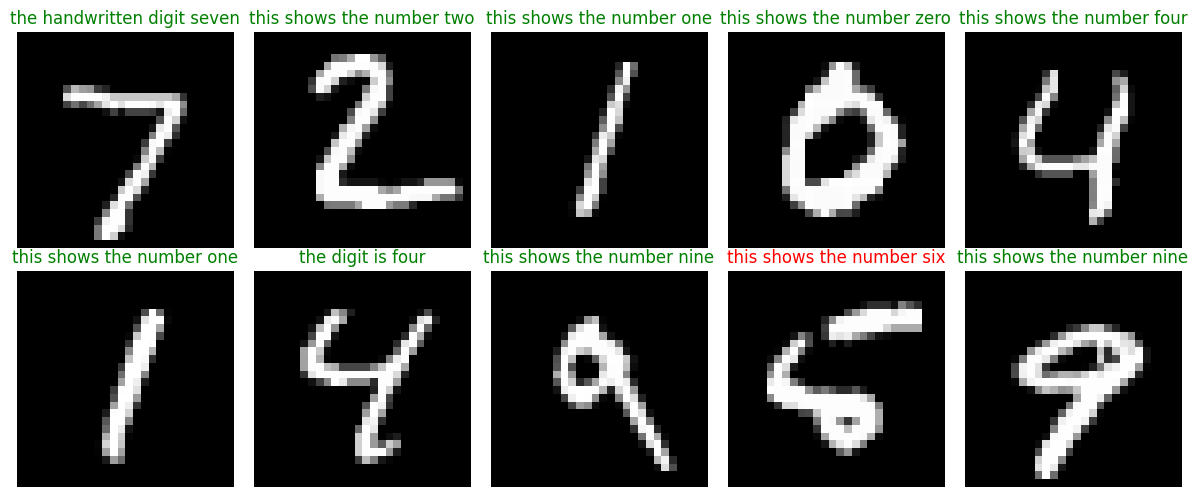

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, lbl in zip(axes.flat, x_test[:10], y_test[:10]):
    cap   = model.caption(jnp.array(img))
    color = 'green' if cap.split()[-1] == DIGIT_NAMES[lbl] else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(cap, color=color)
    ax.axis('off')
plt.tight_layout()

The model learns in a few epochs to predict the correct digit word from the image, demonstrating that the patch tokens carry meaningful visual information and that M-RoPE correctly communicates the spatial layout of those patches to the attention layers.

## What to try next

- **Larger images / more patches**: try 14×14 patches on higher-resolution inputs to see M-RoPE's 2D advantage over 1D position embeddings more clearly.
- **Free-form captions**: replace the templated captions with real image descriptions (e.g. a subset of [COCO Captions](https://cocodataset.org)) and add a pretrained vision encoder (ViT / SigLIP) in place of the raw patch projector.
- **Model parallelism**: add `PartitionSpec` metadata to the weight initialisers as shown in [miniGPT](minigpt.md) to shard the model across multiple devices.